
---

# 🤖 ***`K-Nearest Neighbors (KNN) in Machine Learning for Data Science`***  

---

## ✅ **What is K-Nearest Neighbors (KNN)?**  
📌 **K-Nearest Neighbors (KNN)** is a **supervised learning algorithm** used for both **classification** and **regression** tasks. It is a **non-parametric** and **instance-based** algorithm, meaning it makes predictions based on **memorizing the training data**.  

✅ Simple yet powerful algorithm.  
✅ Effective for **small to medium-sized datasets**.  
✅ Useful for **classification**, **regression**, and **anomaly detection**.  

---

## 🔎 **1. How Does KNN Work?**  

KNN predicts a data point’s class or value by:  

### 🔹 **Step 1: Choose the Value of `K`**  
- `K` represents the **number of nearest neighbors** to consider.  
- Choosing the right `K` is crucial for model performance.  

---

### 🔹 **Step 2: Compute the Distance Between Points**  
- Calculate the distance between the test point and all training points.  
- Common distance metrics include:  
✔️ **Euclidean Distance** (default and most popular)  
$
d = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
$  

✔️ **Manhattan Distance**  
$
d = \sum_{i=1}^n |x_i - y_i|
$  

✔️ **Minkowski Distance** (general form combining Euclidean and Manhattan)  
$
d = \left( \sum_{i=1}^n |x_i - y_i|^p \right)^{1/p}
$

---

### 🔹 **Step 3: Identify the `K` Nearest Neighbors**  
- Select the **K closest points** to the test sample.  
- The choice of `K` directly affects model performance.  

---

### 🔹 **Step 4: Make Predictions**  
✅ **Classification:** Assign the most common class label among the `K` neighbors (majority vote).  
✅ **Regression:** Predict the **average value** of the `K` neighbors.  

---

### 🔹 **Step 5: Evaluate the Model**  
- Measure performance using metrics like **accuracy**, **precision**, or **RMSE**.  

---

## 📊 **2. Choosing the Optimal Value of `K`**  

📌 Selecting the right `K` is crucial:  

✅ **Small `K` (e.g., 1 or 3)** → Model becomes **too flexible**, may lead to **overfitting**.  
✅ **Large `K` (e.g., 20 or 30)** → Model becomes **too rigid**, may lead to **underfitting**.  

**🔍 Rule of Thumb:**  
$
K = \sqrt{n}
$  
Where `n` = number of data points in the training set.  

---

## ⚖️ **3. Bias-Variance Trade-off in KNN**  

| **K Value** | **Bias** | **Variance** | **Model Behavior** |
|:--------------|:-----------|:--------------|:--------------------|
| **Small `K` (e.g., 1-3)** | 🔽 Low Bias | 🔼 High Variance | Model fits noise (Overfitting) |
| **Medium `K` (e.g., 5-10)** | ✅ Balanced | ✅ Balanced | Optimal performance |
| **Large `K` (e.g., 20+)** | 🔼 High Bias | 🔽 Low Variance | Model oversimplifies (Underfitting) |


## 🏹 **4. Implementing KNN in Python**  

### 📁 **Dataset: Iris Flower Classification**  

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using K = 5
knn_model.fit(X_train, y_train)

# Predictions
y_pred = knn_model.predict(X_test)

# Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45




---

## 🔎 **5. Finding the Best Value for `K` Using Cross-Validation**  

📌 Testing different values of `K` helps identify the optimal parameter.  

### 📋 **Python Code: Tuning `K` Using Cross-Validation**

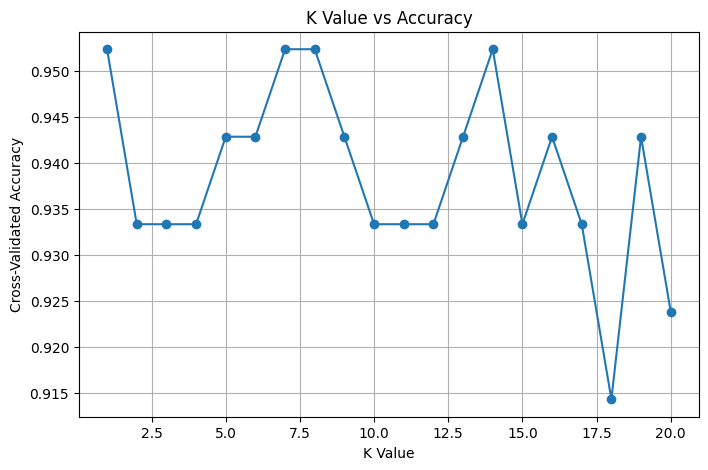

Optimal K: 1


In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Range of K values to test
k_values = range(1, 21)

# Store accuracy scores for each K
accuracy_scores = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='accuracy')
    accuracy_scores.append(scores.mean())

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("K Value vs Accuracy")
plt.xlabel("K Value")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

# Best K
optimal_k = k_values[np.argmax(accuracy_scores)]
print(f"Optimal K: {optimal_k}")


---

## ⚙️ **6. Key Hyperparameters in KNN**  

| **Hyperparameter** | **Description** | **Recommended Value** |
|---------------------|-----------------|------------------------|
| **`n_neighbors`** | Number of nearest neighbors (K). | Optimal K via cross-validation |
| **`metric`** | Distance metric (e.g., `'euclidean'`, `'manhattan'`, `'minkowski'`). | Default = `'minkowski'` |
| **`weights`** | Weight function for voting: `'uniform'` (equal) or `'distance'` (weighted). | `'distance'` for improved performance |
| **`algorithm`** | Algorithm for finding neighbors: `'auto'`, `'ball_tree'`, `'kd_tree'`, `'brute'`. | `'auto'` (chooses the best) |


## ⚠️ **7. Strengths and Weaknesses of KNN**  

### ✅ **Strengths**  
✔️ **Simple and intuitive** algorithm.  
✔️ Requires **no training phase** — just stores data.  
✔️ Effective for **multi-class classification**.  
✔️ Performs well in **low-dimensional datasets**.  

---

### ❌ **Weaknesses**  
❌ **Computationally expensive** for large datasets (since every prediction requires distance calculation).  
❌ **Sensitive to noise** and irrelevant features.  
❌ Performance can degrade in **high-dimensional data** (Curse of Dimensionality).  

---

## 🧠 **8. Techniques to Improve KNN Performance**  

✅ **Feature Scaling** → KNN is distance-based, so scaling data (e.g., with `StandardScaler`) improves performance.  
✅ **Dimensionality Reduction** → Use **PCA** or **Feature Selection** to reduce feature count.  
✅ **Weighted Voting** → Assign greater influence to closer neighbors by setting `weights='distance'`.  
✅ **Choosing the Best K** → Use **cross-validation** to find the optimal `K`.  

---

## 🔥 **9. Real-World Applications of KNN**  

✅ **Healthcare** → Diagnosing diseases based on patient symptoms.  
✅ **Finance** → Credit risk prediction and customer segmentation.  
✅ **Recommendation Systems** → Suggesting similar items or content.  
✅ **Image Recognition** → Classifying handwritten digits (e.g., MNIST dataset).  
✅ **Anomaly Detection** → Identifying unusual behavior in network security.  

---

## 🏆 **10. Key Takeaways**  

✔️ **KNN** is a simple yet powerful **instance-based** learning algorithm.  
✔️ Effective for both **classification** and **regression** tasks.  
✔️ Choosing the **right `K` value** is crucial — use **cross-validation** to tune it.  
✔️ Scaling features improves distance-based algorithms like KNN.  
✔️ Best suited for **small to medium-sized datasets**; alternatives like **Random Forest** or **XGBoost** may be better for large datasets.  

💡 **Pro Tip:** Start with **`K = 5`** and adjust based on your dataset size and complexity.

---


## ***`Further Practice`***

In [7]:
# import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [8]:
# load iris data from sns
df = sns.load_dataset("iris")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
X = df.drop('species',axis=1)
y = df['species']

In [10]:
# load and fit the knn classifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X,y)

new_measurement = np.array([[5.1,3.5,1.4,0.2]])
knn.predict(new_measurement)

array(['setosa'], dtype=object)

In [11]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using K = 5
knn_model.fit(X_train, y_train)

# Predictions
y_pred = knn_model.predict(X_test)

# Model Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



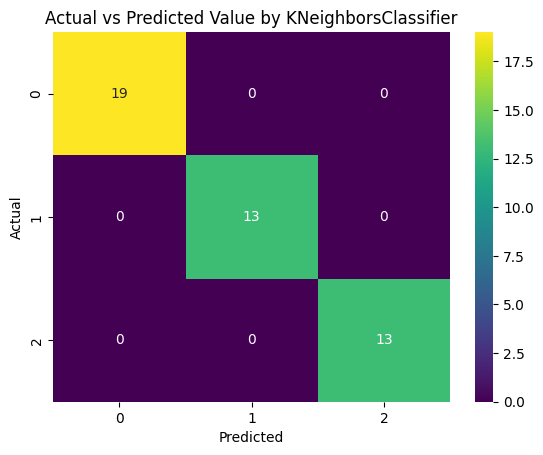

In [14]:
# plt the confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='viridis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Actual vs Predicted Value by KNeighborsClassifier")
plt.show()

---